### STRING GO biological process enrichments

This section plots the GO Process enrichment table from STRING for the full risk-gene set on its own.

In [181]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STRING_BP_PATH = Path("../data/string_enrichments/enrichment.all.tsv")
STRING_BP_SAVE = Path("../results/string_go_process_enrichments.svg")


def load_string_go_process(path):
    enrichment = pd.read_csv(path, sep="\t")
    enrichment = enrichment.loc[enrichment["#category"].eq("GO Process")].copy()
    enrichment = enrichment.assign(
        description=lambda x: x["term description"],
        n_genes=lambda x: pd.to_numeric(x["observed gene count"], errors="coerce"),
        FDR=lambda x: pd.to_numeric(x["false discovery rate"], errors="coerce").clip(lower=np.finfo(float).tiny),
        neglogFDR=lambda x: -np.log10(pd.to_numeric(x["false discovery rate"], errors="coerce").clip(lower=np.finfo(float).tiny)),
        strength=lambda x: pd.to_numeric(x["strength"], errors="coerce"),
        signal=lambda x: pd.to_numeric(x["signal"], errors="coerce"),
    )
    enrichment = enrichment.sort_values(["FDR", "n_genes"], ascending=[True, False])
    return enrichment.loc[:, ["description", "n_genes", "strength", "signal", "FDR", "neglogFDR"]]

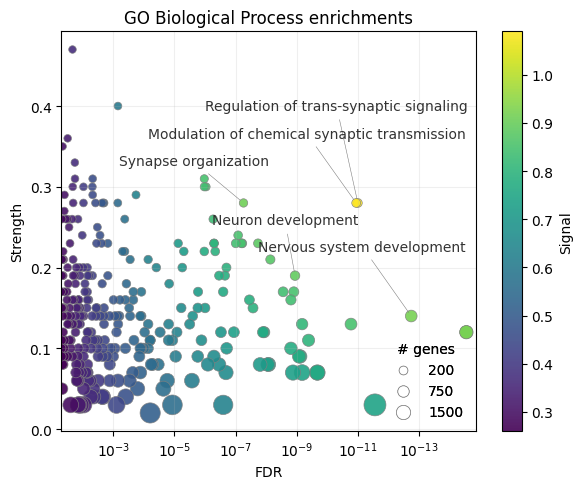

In [213]:
string_bp = load_string_go_process(STRING_BP_PATH)
string_bp_plot = string_bp.loc[string_bp["FDR"] <= 0.05].copy()

if string_bp_plot.empty:
    string_bp_plot = string_bp.copy()

string_bp_plot = string_bp_plot.sort_values("FDR")

manual_label_include = [
    # "Regulation of cell communication",
    "Nervous system development",
    "Neuron development",
    "Modulation of chemical synaptic transmission",
    "Regulation of trans-synaptic signaling",
    "Synapse organization",
]

label_df = string_bp_plot.loc[string_bp_plot["description"].isin(manual_label_include)].copy()

manual_label_offsets = {
    "Regulation of cell communication": (-170, 50),
    "Nervous system development": (-110, 50),
    "Neuron development": (-60, 40),
    "Modulation of chemical synaptic transmission": (-150, 50),
    "Regulation of trans-synaptic signaling": (-110, 70),
    "Synapse organization": (-90, 30),
}

size_min, size_max = 30, 250
if string_bp_plot["n_genes"].max() > string_bp_plot["n_genes"].min():
    point_sizes = np.interp(
        string_bp_plot["n_genes"],
        (string_bp_plot["n_genes"].min(), string_bp_plot["n_genes"].max()),
        (size_min, size_max),
    )
else:
    point_sizes = np.full(len(string_bp_plot), (size_min + size_max) / 2)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    string_bp_plot["FDR"],
    string_bp_plot["strength"],
    s=point_sizes,
    c=string_bp_plot["signal"],
    cmap="viridis",
    edgecolors="grey",
    linewidths=0.5,
    alpha=0.9,
)

for _, row in label_df.iterrows():
    dx, dy = manual_label_offsets.get(row["description"], (-60, 0))
    ax.annotate(
        row["description"],
        (row["FDR"], row["strength"]),
        xytext=(dx, dy),
        textcoords="offset points",
        # ha="right" if dx < 0 else "left",
        ha="left",
        va="center",
        fontsize=10,
        color="#333333",
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.4, shrinkA=3, shrinkB=3),
    )

size_levels = [200, 750, 1500]
size_handles = []
for size_level in size_levels:
    if string_bp_plot["n_genes"].max() > string_bp_plot["n_genes"].min():
        size_value = np.interp(
            size_level,
            (string_bp_plot["n_genes"].min(), string_bp_plot["n_genes"].max()),
            (size_min, size_max),
        )
    else:
        size_value = (size_min + size_max) / 2
    size_handles.append(
        plt.scatter([], [], s=size_value, facecolors="white", edgecolors="grey", linewidths=0.5)
    )
size_legend = ax.legend(
    size_handles,
    [str(x) for x in size_levels],
    title="# genes",
    frameon=False,
    loc="lower right",
    bbox_to_anchor=(1, 0),
)
ax.add_artist(size_legend)

ax.set_xlabel("FDR")
ax.set_ylabel("Strength")
ax.set_title("GO Biological Process enrichments")
ax.set_xscale("log")
ax.set_xlim(0.05, string_bp_plot["FDR"].min() * 0.5)
ax.grid(axis="both", alpha=0.2)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Signal")

fig.tight_layout()
fig.savefig(STRING_BP_SAVE, bbox_inches="tight")
plt.show()

# string_bp_plot

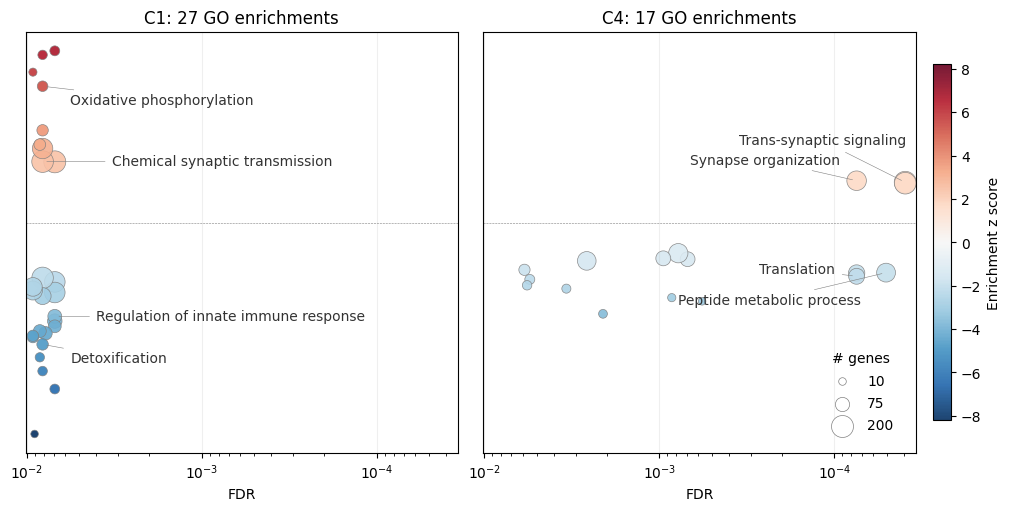

,component,description,n_genes,z_score,FDR,direction
7,C1,Trans-synaptic signaling,198,2.38278,0.006900,bottom
1,C1,Regulation of leukocyte activation,173,-2.29112,0.006900,top
6,C1,Leukocyte activation,172,-2.70280,0.006900,top
3,C1,Response to toxic substance,78,-3.81627,0.006900,top
5,C1,Regulation of innate immune response,70,-3.62943,0.006900,top
2,C1,Positive regulation of response to biotic stim...,58,-4.01964,0.006900,top
4,C1,Mitochondrial ATP synthesis coupled electron t...,29,6.70312,0.006900,bottom
0,C1,Metanephros development,28,-6.45969,0.006900,top
8,C1,Negative regulation of cell activation,66,-4.29159,0.007800,top
13,C1,Chemical synaptic transmission,192,2.39182,0.008100,bottom


In [175]:
component_paths = {
    "C1": "../data/string_enrichments/c1_bp.tsv",
    "C4": "../data/string_enrichments/c4_bp.tsv",
}

def load_component_bp(path, component):
    enrichment = pd.read_csv(path, sep="\t")
    enrichment = enrichment.assign(
        component=component,
        description=lambda x: x["term description"],
        n_genes=lambda x: pd.to_numeric(x["genes mapped"], errors="coerce"),
        FDR=lambda x: pd.to_numeric(x["false discovery rate"], errors="coerce").clip(lower=np.finfo(float).tiny),
        z_score=lambda x: np.where(
            x["direction"].eq("top"),
            -pd.to_numeric(x["enrichment score"], errors="coerce"),
            pd.to_numeric(x["enrichment score"], errors="coerce"),
        ),
    )
    return enrichment.loc[:, ["component", "description", "n_genes", "z_score", "FDR", "direction"]]

component_bp = pd.concat(
    [load_component_bp(path, component) for component, path in component_paths.items()],
    ignore_index=True,
)
component_bp = component_bp.loc[component_bp["FDR"] <= 0.05].copy()
component_bp = component_bp.sort_values(["component", "FDR", "n_genes"], ascending=[True, True, False]).copy()

if component_bp.empty:
    component_bp = pd.concat(
        [load_component_bp(path, component) for component, path in component_paths.items()],
        ignore_index=True,
    ).sort_values(["component", "FDR", "n_genes"], ascending=[True, True, False]).copy()

manual_label_include = {
    "C1": [
        "Oxidative phosphorylation",
        "Regulation of innate immune response",
        "Chemical synaptic transmission",
        "Detoxification",
    ],
    "C4": [
        "Synapse organization",
        "Trans-synaptic signaling",
        "Peptide metabolic process",
        "Translation",
    ],
}
manual_label_offsets = {
    "C1": {
        "Oxidative phosphorylation": (20, -10),
        "Regulation of innate immune response": (30, 0),
        "Chemical synaptic transmission": (50, 0),
        "Detoxification": (20, -10),
    },
    "C4": {
        "Synapse organization": (-120, 15),
        "Trans-synaptic signaling": (-120, 30),
        "Peptide metabolic process": (-150, -20),
        "Translation": (-70, 5),
    },
}

size_min, size_max = 30, 250
z_max = component_bp["z_score"].abs().max()
x_min = component_bp["FDR"].min() * 0.97
x_max = component_bp["FDR"].max() * 1.1

def scale_point_sizes(values):
    if values.max() > values.min():
        return np.interp(values, (values.min(), values.max()), (size_min, size_max))
    return np.full(len(values), (size_min + size_max) / 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained", sharey=True)
axes = np.atleast_1d(axes)
scatter = None

for ax, component in zip(axes, ["C1", "C4"]):
    subset = component_bp.loc[component_bp["component"].eq(component)].copy()
    point_sizes = scale_point_sizes(subset["n_genes"])
    scatter = ax.scatter(
        subset["FDR"],
        subset["z_score"],
        s=point_sizes,
        c=subset["z_score"],
        cmap="RdBu_r",
        vmin=-z_max,
        vmax=z_max,
        edgecolors="grey",
        linewidths=0.5,
        alpha=0.9,
    )

    label_df = subset.loc[subset["description"].isin(manual_label_include.get(component, []))].copy()

    texts = []
    for _, row in label_df.iterrows():
        dx, dy = manual_label_offsets.get(component, {}).get(row["description"], (-60, 0))
        texts.append(
            ax.annotate(
                row["description"],
                (row["FDR"], row["z_score"]),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=10,
                color="#333333",
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.4, shrinkA=3, shrinkB=3),
            )
        )

    ax.axhline(0, color="grey", lw=0.4, ls="--")
    ax.set_xscale("log")
    ax.set_xlim(x_max, x_min*.9)
    ax.get_yaxis().set_visible(False)
    subset_count = subset.shape[0]
    ax.set_title(f"{component}: {subset_count} GO enrichments")
    ax.grid(axis="both", alpha=0.2)
    ax.set_xlabel("FDR")

size_levels = [10, 75, 200]
size_handles = []
reference_sizes = scale_point_sizes(component_bp["n_genes"])
for size_level in size_levels:
    if component_bp["n_genes"].max() > component_bp["n_genes"].min():
        size_value = np.interp(
            size_level,
            (component_bp["n_genes"].min(), component_bp["n_genes"].max()),
            (size_min, size_max),
        )
    else:
        size_value = (size_min + size_max) / 2
    size_handles.append(
        plt.scatter([], [], s=size_value, facecolors="white", edgecolors="grey", linewidths=0.5)
    )

size_legend = fig.legend(
    size_handles,
    [str(x) for x in size_levels],
    title="# genes",
    frameon=False,
    loc="lower right",
    bbox_to_anchor=(.9, 0.12),
    labelspacing=0.6,
)

cbar = fig.colorbar(scatter, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Enrichment z score")

# fig.subplots_adjust(bottom=0.09, top=0.95, hspace=0.18, right=0.88)
fig.savefig("../results/string_component_bp_enrichments.svg", bbox_inches="tight")
plt.show()

component_bp